<a href="https://colab.research.google.com/github/Gediz043/ai/blob/main/beispiel2automultiplelineareregression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [ ]:
# -----------------------------
# 1. Daten erstellen
# -----------------------------
df = pd.DataFrame({
    "Jahr": [2018, 2019, 2020, 2021, 2022, 2023, 2024],
    "Kilometer": [120000, 90000, 110000, 60000, 70000, 30000, 10000],
    "PS": [150, 180, 170, 160, 200, 180, 220],
    "Preis": [21000, 25000, 24000, 27000, 30000, 31000, 34000]
})


In [ ]:
print("Datensatz:")
print(df)


Datensatz:
   Jahr  Kilometer   PS  Preis
0  2018     120000  150  21000
1  2019      90000  180  25000
2  2020     110000  170  24000
3  2021      60000  160  27000
4  2022      70000  200  30000
5  2023      30000  180  31000
6  2024      10000  220  34000


In [ ]:
# -----------------------------
# 2. Eingabe- und Zielvariablen
# -----------------------------
X = df[["Jahr", "Kilometer", "PS"]]
y = df["Preis"]

In [ ]:
# -----------------------------
# 3. Modell erstellen
# -----------------------------
model = LinearRegression()
# Modell trainieren
model.fit(X, y)

LinearRegression()

In [ ]:
print("\nAchsenabschnitt (b):")
print(model.intercept_)

print("\nKoeffizienten (w):")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature:10}: {coef:.2f}")



Achsenabschnitt (b):
-1883072.0838794236

Koeffizienten (w):
Jahr      : 942.33
Kilometer : -0.04
PS        : 48.62


In [ ]:
# -----------------------------
# 5. Güte des Modells
# -----------------------------
print("\nBestimmtheitsmaß R²:")
print(model.score(X, y))



Bestimmtheitsmaß R²:
0.9913856226041254


In [ ]:
# -----------------------------
# 6. Vorhersagen berechnen
# -----------------------------
df["Vorhersage"] = model.predict(X)

print("\nVergleich:")
print(df[["Preis", "Vorhersage"]])


Vergleich:
   Preis    Vorhersage
0  21000  21209.698558
1  25000  24770.642202
2  24000  24453.473132
3  27000  26842.726081
4  30000  29343.381389
5  31000  30859.764089
6  34000  34520.314548


In [ ]:
# -----------------------------
# 7. Neues Auto vorhersagen
# -----------------------------
neues_auto = pd.DataFrame({
    "Jahr": [2025],
    "Kilometer": [20000],
    "PS": [210]
})

preis = model.predict(neues_auto)
print("\nVorhersage für neues Auto:")
print(f"{preis[0]:.2f} Euro")


Vorhersage für neues Auto:
34589.78 Euro


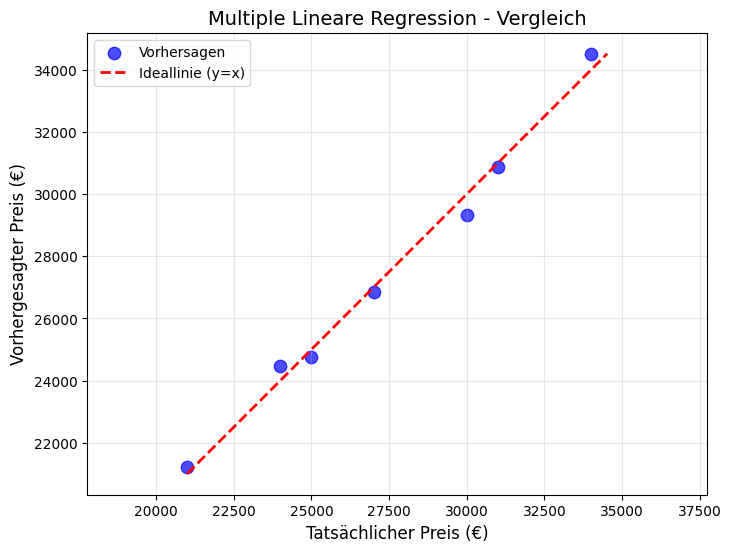

In [ ]:
# -----------------------------
# 8. Tatsächliche gegen vorhergesagte Preise
# -----------------------------
plt.figure(figsize=(8,6))

# Datenpunkte
plt.scatter(df["Preis"], df["Vorhersage"], s=80, color="blue", alpha=0.7, label="Vorhersagen")

# Ideallinie
# Rote Ideallinie
# Ideallinie (y = x)
# 2. Ideallinie berechnen und hinzufügen
minimum = min(df["Preis"].min(), df["Vorhersage"].min())
maximum = max(df["Preis"].max(), df["Vorhersage"].max())
padding = (maximum - minimum) * 0.05

plt.plot([minimum, maximum],
         [minimum, maximum],
         color="red",
         linestyle="--",
         linewidth=2,
         label="Ideallinie (y=x)")
# 3. Achsenbeschriftungen
plt.xlabel("Tatsächlicher Preis (€)", fontsize=12)
plt.ylabel("Vorhergesagter Preis (€)", fontsize=12)
plt.title("Multiple Lineare Regression - Vergleich", fontsize=14)

# Achsenlimits
plt.xlim(minimum - padding, maximum + padding)
plt.ylim(minimum - padding, maximum + padding)

# Grid und Legende
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')
plt.axis('equal')

# ANZEIGEN
plt.show()
